# Линейная регрессия


Линейные методы предполагают, что между признаками объекта и целевой переменной существует линейная зависимость, то есть:
$$ \hat{y} = w_1 x_1 + w_2 x_2 + ... + w_k x_k + b,$$
где $\hat{y}$ - целевая переменная (что мы хотим предсказать), $x_i$ - i-ый признак объекта $x$, $w_i$ - вес $i$-го признака, $b$ - bias (смещение, свободный член).

В задаче линейной регрессии $\hat{y}$ - это действительное число.

Часто для упрощения записи вводят дополнительный фиктивный признак $x_0$, который всегда равен 1, тогда bias - вес этого признака. В этом случае формула может быть записана как скалярное произведение:
$$ \hat{y} = <w, x> $$

В матричной форме формулу можно переписать следующим образом:
$$ \hat{y} = Xw,$$
$\hat{y}$ - вектор значений целевой переменной размера $n$, $X$ - матрица значений признаков объектов размера $n \times k$, w - вектор весов размера $k$. То есть в наших данных имеется $n$ объектов, каждый их которых описан $k$ признаками.

Таким образом, в матричной форме модель задаётся следующим образом:
$$ y = Xw + \epsilon$$

Важно отметить, что параметрами этой модели являются веса $w$. Когда говорят об обучении какого-либо алгоритма машинного обучения, как правило, имеют в виду настройку весов, т.е. параметров модели.  

На практике $\hat{y} $ может отличается от реальных значений, которые принимает целевая переменная $y$. Разницу между реальным значением и предсказанным, обозначим как $\epsilon$ - вектор значений случайной переменной, соответствующая случайной, непрогнозируемой ошибке модели. Ограничения, которые накладываются на эту модель:
* математическое ожидание случайных ошибок $\epsilon$ равно нулю,
* дисперсия случайных ошибок одинакова и конечна,
* случайные ошибки не скоррелированы.

Один из способов вычислить значения параметров модели, давно знаком - это наименьших квадратов, который минимизирует среднеквадратичную ошибку между реальным значением зависимой переменной и прогнозом, выданным моделью. Решение по методу наименьших квадратов дает:
$$ w = (X^TX)^{-1}X^TY $$

Загрузим необходимые библиотеки

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

## Оценка результатов

Чтобы оценить качество работы алгоритма нам необходимо применяют разные метрики. Наиболее частые метрики средневадратичная и средняя абсолютная ошибки. Вычислим эти метрики на обучающей и на тестовой выборках.

 * *mean_absolute_error* - средняя абсолютная ошибка $|y_i - \hat{y}_i|$
 * *mean_squared_error* - средняя квадратичная ошибка $(y_i - \hat{y}_i)^2$

## Задание 3.1

Пример 1. Сгенерируем искусственные данные. Сначала поработаем с простейшим одномерным случаем, когда у нас значение $y$ будет зависеть только от одного значения $x$.




In [ ]:
def generate_data(n_points=20):
  """
    Принимает на вход n_points точек
    Возвращает данные для обучения и теста
  """
  X = np.linspace(-5, 5, n_points)
  y = 10 * X - 7

  X_train = X[0::2].reshape(-1, 1)
  y_train = y[0::2] + np.random.randn(int(n_points/2)) * 10

  X_test = X[1::2].reshape(-1, 1)
  y_test = y[1::2] + np.random.randn(int(n_points/2)) * 10

  print(f'Generated {len(X_train)} train samples and {len(X_test)} test samples')
  return X, X_train, y_train, X_test, y_test

In [ ]:
X, X_train, y_train, X_test, y_test = generate_data(100)
X

Generated 50 train samples and 50 test samples


array([-5.        , -4.8989899 , -4.7979798 , -4.6969697 , -4.5959596 ,
       -4.49494949, -4.39393939, -4.29292929, -4.19191919, -4.09090909,
       -3.98989899, -3.88888889, -3.78787879, -3.68686869, -3.58585859,
       -3.48484848, -3.38383838, -3.28282828, -3.18181818, -3.08080808,
       -2.97979798, -2.87878788, -2.77777778, -2.67676768, -2.57575758,
       -2.47474747, -2.37373737, -2.27272727, -2.17171717, -2.07070707,
       -1.96969697, -1.86868687, -1.76767677, -1.66666667, -1.56565657,
       -1.46464646, -1.36363636, -1.26262626, -1.16161616, -1.06060606,
       -0.95959596, -0.85858586, -0.75757576, -0.65656566, -0.55555556,
       -0.45454545, -0.35353535, -0.25252525, -0.15151515, -0.05050505,
        0.05050505,  0.15151515,  0.25252525,  0.35353535,  0.45454545,
        0.55555556,  0.65656566,  0.75757576,  0.85858586,  0.95959596,
        1.06060606,  1.16161616,  1.26262626,  1.36363636,  1.46464646,
        1.56565657,  1.66666667,  1.76767677,  1.86868687,  1.96

In [ ]:
### Реализуйте настройку w и b с помощью рассмотренного выше метода наименьших квадратов.
### Найдите значения метрик MSE и MAE. Сравните с результатами из sklearn

In [ ]:
#вводим фиктивный признак, равный 1
X_train_b = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_train_b

array([[ 1.        , -5.        ],
       [ 1.        , -4.7979798 ],
       [ 1.        , -4.5959596 ],
       [ 1.        , -4.39393939],
       [ 1.        , -4.19191919],
       [ 1.        , -3.98989899],
       [ 1.        , -3.78787879],
       [ 1.        , -3.58585859],
       [ 1.        , -3.38383838],
       [ 1.        , -3.18181818],
       [ 1.        , -2.97979798],
       [ 1.        , -2.77777778],
       [ 1.        , -2.57575758],
       [ 1.        , -2.37373737],
       [ 1.        , -2.17171717],
       [ 1.        , -1.96969697],
       [ 1.        , -1.76767677],
       [ 1.        , -1.56565657],
       [ 1.        , -1.36363636],
       [ 1.        , -1.16161616],
       [ 1.        , -0.95959596],
       [ 1.        , -0.75757576],
       [ 1.        , -0.55555556],
       [ 1.        , -0.35353535],
       [ 1.        , -0.15151515],
       [ 1.        ,  0.05050505],
       [ 1.        ,  0.25252525],
       [ 1.        ,  0.45454545],
       [ 1.        ,

In [ ]:
weights = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train
b_mnk = weights[0]
w_mnk = weights[1]
b_mnk, w_mnk

(np.float64(-8.160264036092325), np.float64(10.124749905305316))

In [ ]:
X_test_b = np.hstack([np.ones((X_test.shape[0], 1)), X_test])
y_pred_mnk = X_test_b @ weights

In [ ]:
mse_mnk_test = np.mean((y_test - y_pred_mnk) ** 2)
mae_mnk_test = np.mean(np.abs(y_test - y_pred_mnk))
mse_mnk_test, mae_mnk_test

(np.float64(103.47492932427238), np.float64(8.003887295472246))

In [ ]:
#реализация через sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

w = model.coef_
b = model.intercept_
w, b

(array([10.12474991]), np.float64(-8.160264036092327))

In [ ]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse, mae

(93.63818944926855, 7.604033369384594)

## Задание 3.2

Пример 2. Не всегда в задаче регрессии в качестве решения выступает прямая, как в предыдущем случае. Рассмотрим ещё один пример, в котором у объектов всё ещё один признак. Но теперь мы будм брать случайную точку на синусоиде и добавлять к ней шум — таким образом получим целевую переменную, признаком в этом случае будет координата $x$.

In [ ]:
def generate_wave_set(n_support=1000, n_train=25, std=0.3):
    data = {}
    # выберем некоторое количество точек из промежутка от 0 до 2*pi
    data['support'] = np.linspace(0, 2*np.pi, num=n_support)
    # для каждой посчитаем значение sin(x) + 1
    # это будет ground truth
    data['values'] = np.sin(data['support']) + 1
    # из support посемплируем некоторое количество точек с возвратом, это будут признаки
    data['x_train'] = np.sort(np.random.choice(data['support'], size=n_train, replace=True))
    # опять посчитаем sin(x) + 1 и добавим шум, получим целевую переменную
    data['y_train'] = np.sin(data['x_train']) + 1 + np.random.normal(0, std, size=data['x_train'].shape[0])
    return data

data = generate_wave_set(1000, 250)

In [ ]:
### попробуйте реализовать настройку w и b с помощью рассмотренного выше метода наименьших квадратов.
### Найдите значения метрик MSE и MAE

In [ ]:
X_train = data['x_train']
y_train = data['y_train']

X_train_reshaped = X_train.reshape(-1, 1)
X_train_reshaped

array([[0.06289475],
       [0.06918422],
       [0.08176317],
       [0.08176317],
       [0.13836845],
       [0.23271057],
       [0.25157899],
       [0.25786847],
       [0.28302637],
       [0.30818426],
       [0.31447374],
       [0.32076321],
       [0.37736849],
       [0.42768429],
       [0.43397376],
       [0.43397376],
       [0.44026323],
       [0.44026323],
       [0.46542113],
       [0.49057903],
       [0.51573693],
       [0.54718431],
       [0.56605273],
       [0.57234221],
       [0.65410538],
       [0.66039485],
       [0.6729738 ],
       [0.72957907],
       [0.76731592],
       [0.7987633 ],
       [0.84278962],
       [0.86165805],
       [0.88681594],
       [0.89310542],
       [0.92455279],
       [0.93713174],
       [0.96857912],
       [1.01260544],
       [1.06921071],
       [1.15726336],
       [1.17613178],
       [1.18871073],
       [1.22644758],
       [1.22644758],
       [1.28934233],
       [1.31450023],
       [1.32707918],
       [1.440

In [ ]:
X_train_b = np.hstack([np.ones((X_train_reshaped.shape[0], 1)), X_train_reshaped])
X_train_b

array([[1.        , 0.06289475],
       [1.        , 0.06918422],
       [1.        , 0.08176317],
       [1.        , 0.08176317],
       [1.        , 0.13836845],
       [1.        , 0.23271057],
       [1.        , 0.25157899],
       [1.        , 0.25786847],
       [1.        , 0.28302637],
       [1.        , 0.30818426],
       [1.        , 0.31447374],
       [1.        , 0.32076321],
       [1.        , 0.37736849],
       [1.        , 0.42768429],
       [1.        , 0.43397376],
       [1.        , 0.43397376],
       [1.        , 0.44026323],
       [1.        , 0.44026323],
       [1.        , 0.46542113],
       [1.        , 0.49057903],
       [1.        , 0.51573693],
       [1.        , 0.54718431],
       [1.        , 0.56605273],
       [1.        , 0.57234221],
       [1.        , 0.65410538],
       [1.        , 0.66039485],
       [1.        , 0.6729738 ],
       [1.        , 0.72957907],
       [1.        , 0.76731592],
       [1.        , 0.7987633 ],
       [1.

In [ ]:
weights = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train
b = weights[0]
w = weights[1]
b, w

(np.float64(1.8879748888029428), np.float64(-0.286149422249906))

In [ ]:
y_pred = X_train_b @ weights

In [ ]:
mse = np.mean((y_train - y_pred) ** 2)
mae = np.mean(np.abs(y_train - y_pred))
mse, mae

(np.float64(0.28552790427998875), np.float64(0.44154750430180867))

Конечно, такое решение нас вряд ли может устроить. Нужно применить полинимиальную регрессию. Идея здесь такая. Каждый признак в исходную формулу может входить не только в первой степени, но и во второй, в третьей и так далее. То есть для случая, когда у нас только один признак:
$$ \widehat{y} = w_1 x_1 + w_2 x_1^2 + ... + w_k x_1^k + b,$$

## Задание 3.3

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

### Реализуйте полиномиальную регрессию. Сделайте визуализацию для полиномов разных степеней.
### Полином какой степени подходит больше других? Почему?

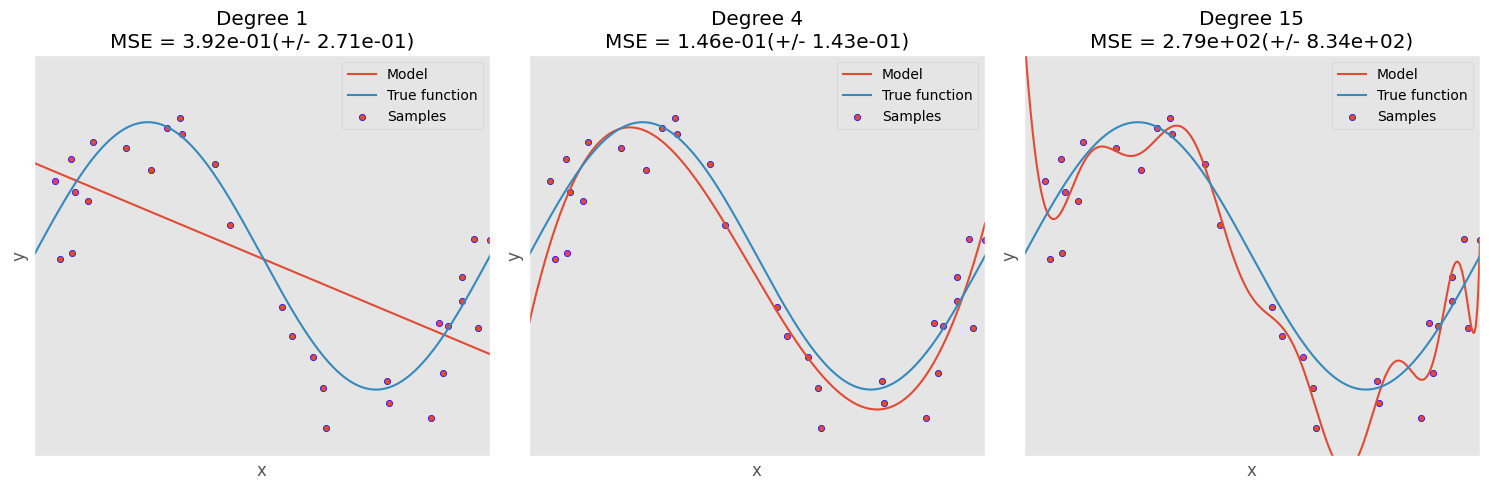

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

data = generate_wave_set(1000, 30)

X = data['x_train']
y = data['y_train']
degrees = [1, 4, 15]

plt.figure(figsize=(15, 5))
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degrees[i],
                                             include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    pipeline.fit(X[:, np.newaxis], y)
    # Evaluate the models using crossvalidation
    scores = cross_val_score(pipeline, X[:, np.newaxis], y,
                             scoring="neg_mean_squared_error", cv=10)

    X_test = data['support']
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    plt.plot(X_test, data['values'], label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 2 * np.pi))
    plt.ylim((-0.5, 2.5))
    plt.legend(loc="best")
    plt.title("Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(
        degrees[i], -scores.mean(), scores.std()))

plt.tight_layout()
plt.show()

#лучше подошел полином 4 степени, так как 15-я степень пытается "зацепить" каждую точку,
#следовательно, не будет подходить для работы с новыми данными. Линейная функция, наоборот, слишком обобщает распределение данных

# Реальный датасет

Возьмём реальный набор данных Boston из sklearn.datasets. Этот датасет описывает средние цены на недвижимость в районах Бостона в тысячах долларов.

Примеры признаков объектов недвижимости: количество преступлений на душу населения, процент старых домов в районе, количество учеников на одного учителя и т.д. Обратите внимание на то, что данные уже оцифрованы там, где изначально признаки были качественными.

Загрузим датасет, выведем информацию

In [ ]:
#from sklearn.datasets import load_boston

Возьмите датасет отсюда: https://www.kaggle.com/datasets/vikrishnan/boston-house-prices/

In [ ]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_9457/16828617.py:2: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [ ]:
raw_df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,0.00632,18.00,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3
1,396.90000,4.98,24.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.02731,0.00,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8
3,396.90000,9.14,21.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.02729,0.00,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8


## Задание 3.4

In [ ]:
### оставьте в наборе данных только 7 наиболее значимых признаков
### настройте параметры линейной регрессии и сравните метрики качества (MSE и MAE) для полного датасета и усечённого

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=33)

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

In [ ]:
selector = SelectKBest(score_func=f_regression, k=7)
selector.fit(X_train, y_train)

top_7_indices = np.where(selector.get_support())[0]
print(top_7_indices)

[ 0  2  4  5  9 10 12]


In [ ]:
X_train_cut = X_train[:, top_7_indices]
X_test_cut = X_test[:, top_7_indices]

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
model_cut = model.fit(X_train_cut, y_train)
y_pred_cut = model_cut.predict(X_test_cut)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse, mae

(22.04257921621332, 3.5237844319690894)

In [ ]:
mse_cut = mean_squared_error(y_test, y_pred_cut)
mae_cut = mean_absolute_error(y_test, y_pred_cut)
mse_cut, mae_cut

(26.440601322534185, 3.872458012381687)